# 04 · When the coverage guarantee breaks — the curation punchline
Conformal prediction guarantees coverage **only under exchangeability**. Across sites, exchangeability fails (we measured AUC ≈ 1.0 in notebook 01). Here we show the consequence directly: a model calibrated at one hospital can **silently under-cover** at another — *confident but wrong*, the worst failure mode for cross-institution deployment.

In [1]:
# --- workshop bootstrap: make the package importable ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)

## Train the federated model (holding out Switzerland)

In [2]:
train_sites = ['cleveland', 'hungarian', 'va']
fed = federated.federated_averaging(sites, rounds=200, local_epochs=3,
                                    train_sites=train_sites, seed=0)
model = fed.global_model
alpha = 0.1

## Calibrate at Cleveland, deploy everywhere

In [3]:
sd_c = sites['cleveland']
cp = conformal.LACPredictor(alpha=alpha).calibrate(model.predict_proba(sd_c.X), sd_c.y)
cov_by_site = {s: ev.coverage(cp.predict_set(model.predict_proba(sites[s].X)), sites[s].y)
               for s in data.SITES}
cov_by_site

{'cleveland': 0.9075907590759076,
 'hungarian': 0.9047619047619048,
 'switzerland': 0.6991869918699187,
 'va': 0.91}

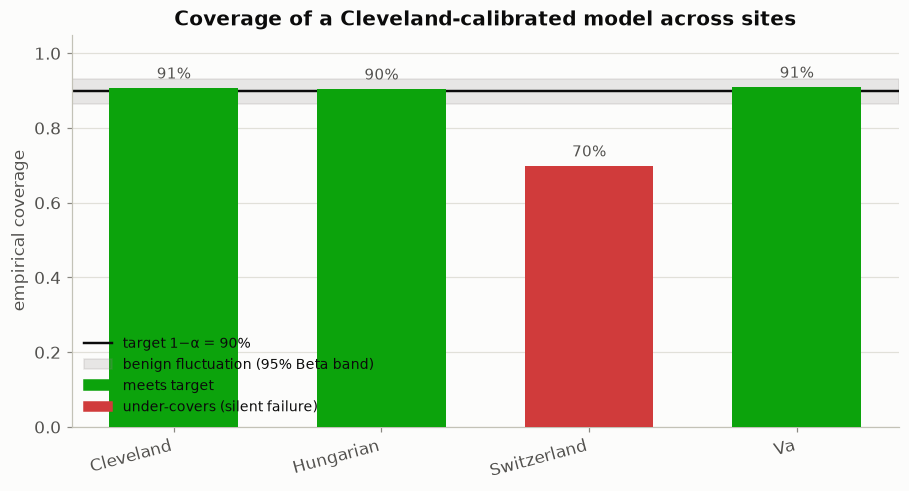

In [4]:
viz.plot_coverage_by_site(cov_by_site, alpha, n_cal=sd_c.n,
        title='Coverage of a Cleveland-calibrated model across sites');

Cleveland and Hungary land on the 90% target; **Switzerland falls to ~82%**, well below the benign-fluctuation band. The guarantee did not travel with the model.

## The full transfer matrix
Calibrate at site *i* (row), deploy at site *j* (column). The diagonal is honest; the off-diagonal drops quantify how far the guarantee degrades.

,cleveland,hungarian,switzerland,va
cleveland,0.91,0.90,0.70,0.91
hungarian,0.91,0.91,0.70,0.92
switzerland,0.99,0.97,0.92,0.99
va,0.90,0.90,0.70,0.91


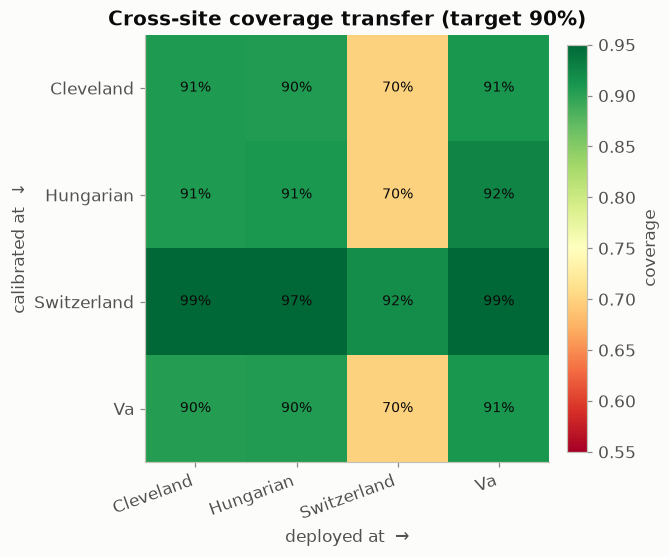

In [5]:
cov = pd.DataFrame(index=data.SITES, columns=data.SITES, dtype=float)
for si in data.SITES:
    c = conformal.LACPredictor(alpha=alpha).calibrate(model.predict_proba(sites[si].X), sites[si].y)
    for sj in data.SITES:
        cov.loc[si, sj] = ev.coverage(c.predict_set(model.predict_proba(sites[sj].X)), sites[sj].y)
display(cov.astype(float).round(2))
viz.plot_transfer_matrix(cov.astype(float), alpha);

## Adaptivity: are the sets bigger where the model is unsure?

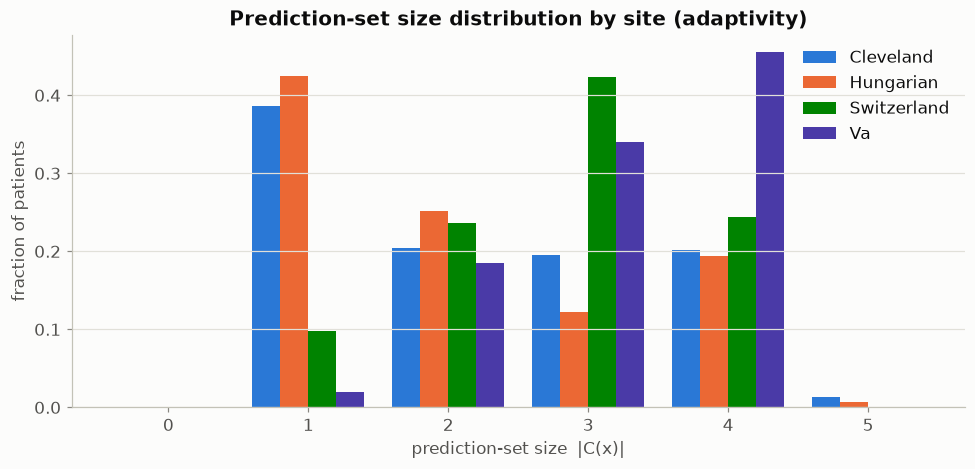

In [6]:
sizes = {s: ev.set_sizes(cp.predict_set(model.predict_proba(sites[s].X))) for s in data.SITES}
viz.plot_set_size_distribution(sizes, n_classes=sd_c.n_classes);

## Why calibration-set size matters

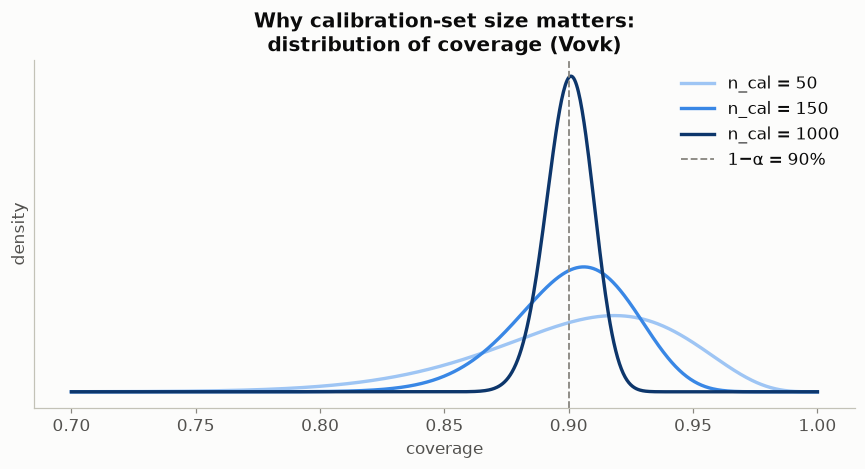

In [7]:
viz.plot_coverage_beta(alpha=0.1, ns=(50, 150, 1000));

## Takeaways for research-data curation
1. **Interoperability ≠ comparability.** Measure site heterogeneity *before* integrating (notebook 01).
2. **Conformal coverage is only marginal & exchangeable.** Report coverage *per site*, not just pooled — a pooled 90% can hide a site at 82%.
3. **Cross-site coverage drop is a curation signal.** A large off-diagonal drop tells you a site's data or measurement process differs enough to break transfer.
4. **Mitigations to explore next:** per-site (group-balanced) calibration, conformal under covariate shift (importance weighting), and flagging measurement-heterogeneous features before they enter the model.


### Capstone exercise
Implement **per-site calibration**: calibrate a separate `q̂` for each site and re-draw the coverage-by-site chart. Does group-balanced calibration restore 90% coverage at Switzerland? What did you have to assume to do it (hint: you needed labelled data *at* Switzerland)?